## Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Membaca Gambar dan merubah ke RGB

In [2]:
#Membaca gambar dan merubah ke RGB
image = cv2.imread('Gambar1.jpeg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

## Hasil dari Gambar Asli

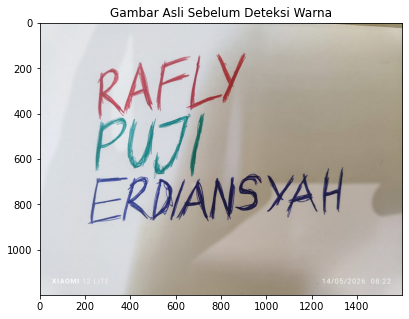

In [3]:
#Menampilkan hasilnya
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Gambar Asli Sebelum Deteksi Warna")
plt.show()

## Mendeteksi Warna Merah

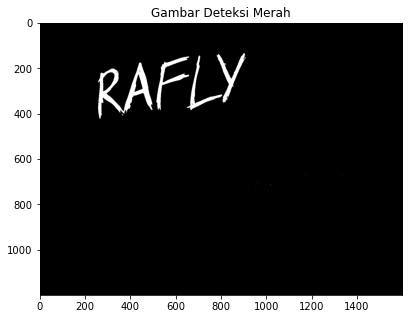

In [4]:
#nilai batas bawah untuk Red
nBawah_red1 = np.array([0, 80, 80])
nAtas_red1 = np.array([10, 255, 255])
nMask_red1 = cv2.inRange(image_hsv, nBawah_red1, nAtas_red1)

#nilai batas atas untuk Red
nBawah_red2 = np.array([170, 40, 40])
nAtas_red2 = np.array([180, 255, 255])
nMask_red2 = cv2.inRange(image_hsv, nBawah_red2, nAtas_red2)

nMask_red = cv2.bitwise_or(nMask_red1, nMask_red2)

#Menampilkan hasil deteksi merah
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 2)
plt.imshow(nMask_red, cmap='gray')
plt.title("Gambar Deteksi Merah")
plt.show()

## Mendeteksi Warna Hijau

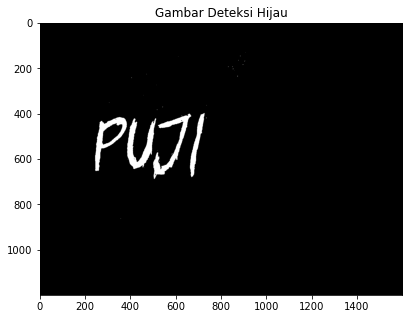

In [5]:
#nilai untuk Green
nBawah_green = np.array([35, 15, 15]) 
nAtas_green = np.array([100, 255, 255])

nMask_green = cv2.inRange(image_hsv, nBawah_green, nAtas_green)

#Menampilkan hasil deteksi hijau
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 2)
plt.imshow(nMask_green, cmap='gray')
plt.title("Gambar Deteksi Hijau")
plt.show()

## Mendeteksi Warna Biru

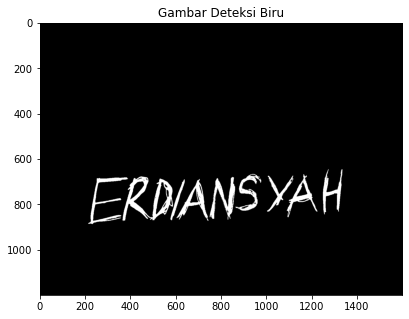

In [6]:
#nilai untuk Blue
nBawah_blue = np.array([105, 40, 40])
nAtas_blue = np.array([140, 255, 255])

nMask_blue = cv2.inRange(image_hsv, nBawah_blue, nAtas_blue)

#Menampilkan hasil deteksi biru
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 2)
plt.imshow(nMask_blue, cmap='gray')
plt.title("Gambar Deteksi Biru")
plt.show()

## Histogram untuk per deteksi warna

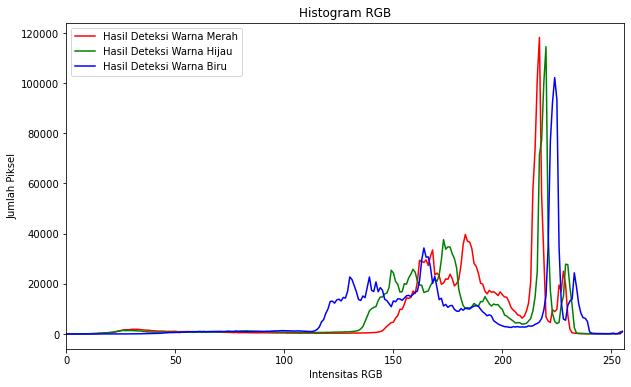

In [7]:
plt.figure(figsize=(10, 6))

colors = ('red', 'green', 'blue')

for i, color in enumerate(colors):
    hist = cv2.calcHist(
        [image_rgb], [i], None, [256], [0, 256]
    )
    
    plt.plot(hist, color=color, label=color)
    
plt.title("Histogram RGB")
plt.xlabel("Intensitas RGB")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 256])

plt.legend(['Hasil Deteksi Warna Merah', 'Hasil Deteksi Warna Hijau', 'Hasil Deteksi Warna Biru'])
plt.show()

## Menampilkan Nilai Ambang Batasnya

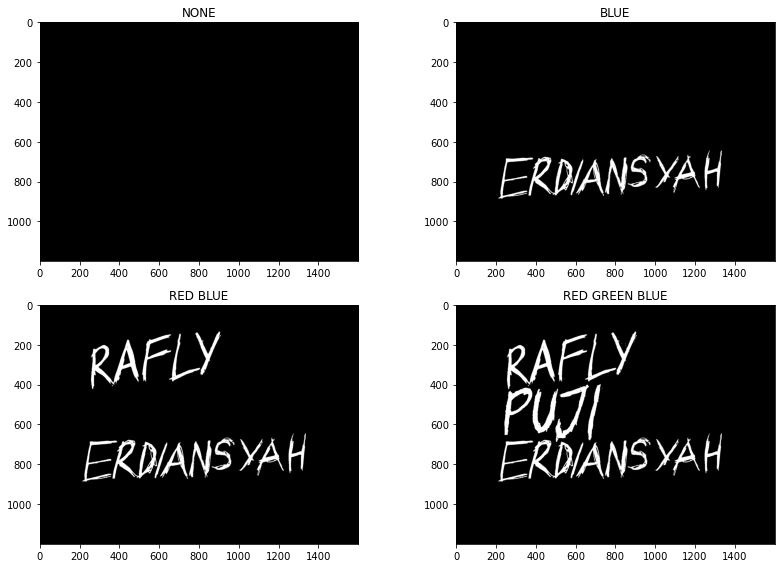

In [8]:
plt.figure(figsize=(12 , 8))
#Menampilkan Gambar NONE
none = np.zeros_like(nMask_red)

plt.subplot(2, 2, 1)
plt.imshow(none, cmap='gray')
plt.title("NONE")

#Menampilkan Gambar BIRU
biru = nMask_blue

plt.subplot(2, 2, 2)
plt.imshow(biru, cmap='gray')
plt.title("BLUE")

#Menampilkan RED BLUE
RedBlue = cv2.bitwise_or(nMask_red, nMask_blue)

plt.subplot(2, 2, 3)
plt.imshow(RedBlue, cmap='gray')
plt.title("RED BLUE")

#Menampilkan RED GREEN BLUE
rgb = cv2.bitwise_or(RedBlue, nMask_green)

plt.subplot(2, 2, 4)
plt.imshow(rgb, cmap='gray')
plt.title("RED GREEN BLUE")

plt.tight_layout()
plt.show()